# PREDICCIÓN DEL CHURN

**Fuente:** *https://www.kaggle.com/datasets/shubhammeshram579/bank-customer-churn-prediction*

About Dataset
The bank customer churn dataset is a commonly used dataset for predicting customer churn in the banking industry. It contains information on bank customers who either left the bank or continue to be a customer. The dataset includes the following attributes:

* Customer ID: A unique identifier for each customer
* Surname: The customer's surname or last name
* Credit Score: A numerical value representing the customer's credit score
* Geography: The country where the customer resides (France, Spain or Germany)
* Gender: The customer's gender (Male or Female)
* Age: The customer's age.
* Tenure: The number of years the customer has been with the bank
* Balance: The customer's account balance
* NumOfProducts: The number of bank products the customer uses (e.g., savings account, credit card)
* HasCrCard: Whether the customer has a credit card (1 = yes, 0 = no)
* IsActiveMember: Whether the customer is an active member (1 = yes, 0 = no)
* EstimatedSalary: The estimated salary of the customer
* Exited: Whether the customer has churned (1 = yes, 0 = no)

*Gerson Jesus Torrez Marca*


In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from imblearn.over_sampling import RandomOverSampler


## CARGAMOS LOS DATOS

In [2]:
data = pd.read_csv('Customer-Churn-Records.csv')
data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


In [3]:
data.drop(columns=['RowNumber', 'Surname'], inplace=True)

In [4]:
data.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [5]:
data.describe(include='object')

,Geography,Gender,Card Type
count,10000,10000,10000
unique,3,2,4
top,France,Male,DIAMOND
freq,5014,5457,2507


In [6]:
data.isnull().sum()

CustomerId            0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [7]:
categorical_features = data.select_dtypes(include=['object']).columns
numerical_features = data.select_dtypes(exclude=['object']).columns[1:]

## EXPLORATORY DATA ANALYSIS AND DATA CLEANING

In [8]:
cols = 3
rows = -(-len(categorical_features) // cols)

fig = make_subplots(rows=rows, cols=cols, subplot_titles=[f'{feature}' for feature in categorical_features])

colors = ['lightblue', 'skyblue']

for i, feature in enumerate(categorical_features):
    row = i // cols + 1
    col = i % cols + 1
    for target_value in data['Exited'].unique():
        filtered_data = data[data['Exited'] == target_value]
        fig.add_trace(
            go.Histogram(
                x=filtered_data[feature],
                name=f'{target_value}',
                marker_color=colors[int(target_value)],
                showlegend=(i == 0)
            ),
            row=row,
            col=col
        )

fig.update_layout(
    height=400,
    width=1200,
    title_text='Categorical features per term_deposit (Target)',
    barmode='overlay',
)

fig.update_traces(opacity=0.6)
fig.show()

In [9]:
cols = 3
rows = -(-len(numerical_features) // cols)

fig = make_subplots(rows=rows, cols=cols, subplot_titles=[f'{feature}' for feature in numerical_features])

for i, feature in enumerate(numerical_features):
    row = i // cols + 1
    col = i % cols + 1
    for target_value in data['Exited'].unique():
        filtered_data = data[data['Exited'] == target_value]
        fig.add_trace(
            go.Histogram(
                x=filtered_data[feature],
                name=f'{target_value}',
                marker_color=colors[int(target_value)],
                showlegend=(i == 0)
            ),
            row=row,
            col=col
        )

fig.update_layout(
    height=800,
    width=1200,
    title_text='Numerical features per term_deposit (Target)',
    barmode='overlay',
)

fig.update_traces(opacity=0.6)
fig.show()

In [10]:
fig = make_subplots(
    rows=rows, 
    cols=cols, 
    subplot_titles=[f'Boxplot de {feature}' for feature in numerical_features]
)

for i, feature in enumerate(numerical_features):
    row = i // cols + 1
    col = i % cols + 1
    fig.add_trace(
        go.Box(
            y=data[feature],
            name=feature,
            marker_color=colors[int(target_value)],
            boxmean=True,
            showlegend=False
        ),
        row=row,
        col=col
    )

fig.update_layout(
    height=rows * 280,
    width=1400,
    title_text='Boxplots de características numéricas (Totales)',
)

fig.show()

In [11]:
label_encoders = {}
categorical_features = data.select_dtypes(include=['object']).columns.tolist()

data_encoded = data.copy()

for col in categorical_features:
    le = LabelEncoder()
    data_encoded[col] = le.fit_transform(data[col])
    label_encoders[col] = le  
    
data_encoded

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,15634602,619,0,0,42,2,0.00,1,1,1,101348.88,1,1,2,0,464
1,15647311,608,2,0,41,1,83807.86,1,0,1,112542.58,0,1,3,0,456
2,15619304,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1,3,0,377
3,15701354,699,0,0,39,1,0.00,2,0,0,93826.63,0,0,5,1,350
4,15737888,850,2,0,43,2,125510.82,1,1,1,79084.10,0,0,5,1,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,0,1,39,5,0.00,2,1,0,96270.64,0,0,1,0,300
9996,15569892,516,0,1,35,10,57369.61,1,1,1,101699.77,0,0,5,2,771
9997,15584532,709,0,0,36,7,0.00,1,0,1,42085.58,1,1,3,3,564
9998,15682355,772,1,1,42,3,75075.31,2,1,0,92888.52,1,1,2,1,339


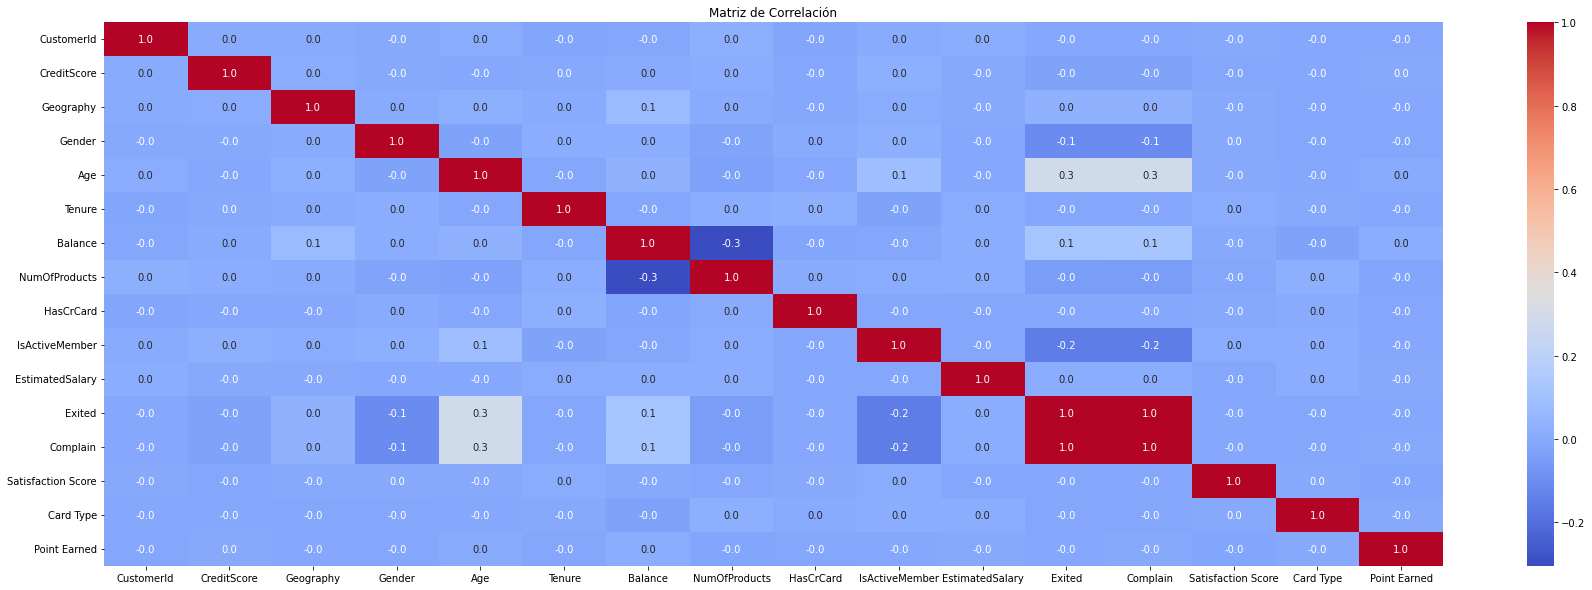

In [12]:
correlation_matrix = data_encoded.corr(numeric_only=True)

plt.figure(figsize=(30, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()

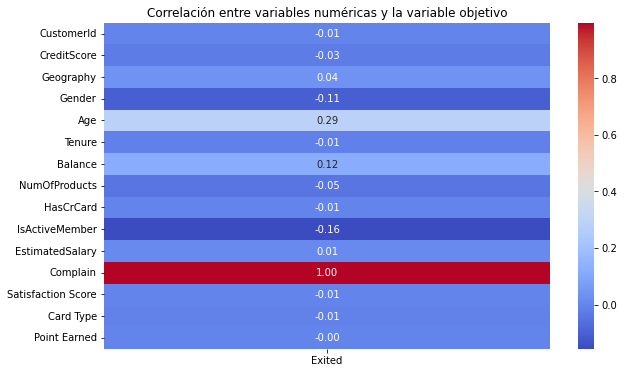

In [13]:
correlation_with_target = data_encoded.corr()['Exited'].drop('Exited')

plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_with_target.to_frame(),
    annot=True,
    cmap='coolwarm',
    cbar=True,
    fmt=".2f"
)
plt.title('Correlación entre variables numéricas y la variable objetivo')
plt.show()

In [14]:
data_encoded.drop(columns=['Complain'], inplace=True)

In [15]:
data_encoded['Exited'].value_counts()

0    7962
1    2038
Name: Exited, dtype: int64

## PREPARATION FOR MODELING

In [16]:
# Move the 'Exited' column to the end
data_encoded = data_encoded[[col for col in data_encoded.columns if col != 'Exited'] + ['Exited']]
data_encoded

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Satisfaction Score,Card Type,Point Earned,Exited
0,15634602,619,0,0,42,2,0.00,1,1,1,101348.88,2,0,464,1
1,15647311,608,2,0,41,1,83807.86,1,0,1,112542.58,3,0,456,0
2,15619304,502,0,0,42,8,159660.80,3,1,0,113931.57,3,0,377,1
3,15701354,699,0,0,39,1,0.00,2,0,0,93826.63,5,1,350,0
4,15737888,850,2,0,43,2,125510.82,1,1,1,79084.10,5,1,425,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,0,1,39,5,0.00,2,1,0,96270.64,1,0,300,0
9996,15569892,516,0,1,35,10,57369.61,1,1,1,101699.77,5,2,771,0
9997,15584532,709,0,0,36,7,0.00,1,0,1,42085.58,3,3,564,1
9998,15682355,772,1,1,42,3,75075.31,2,1,0,92888.52,2,1,339,1


In [17]:
X = data_encoded.iloc[:,1:-1]
y = data_encoded.iloc[:,-1]

In [18]:
X

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Satisfaction Score,Card Type,Point Earned
0,619,0,0,42,2,0.00,1,1,1,101348.88,2,0,464
1,608,2,0,41,1,83807.86,1,0,1,112542.58,3,0,456
2,502,0,0,42,8,159660.80,3,1,0,113931.57,3,0,377
3,699,0,0,39,1,0.00,2,0,0,93826.63,5,1,350
4,850,2,0,43,2,125510.82,1,1,1,79084.10,5,1,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,1,0,300
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,5,2,771
9997,709,0,0,36,7,0.00,1,0,1,42085.58,3,3,564
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,2,1,339


In [19]:
sm = RandomOverSampler()
X, y = sm.fit_resample(X, y)

# sm = SMOTE(random_state=42)
# X, y = sm.fit_resample(X, y)

In [ ]:
# sc = MinMaxScaler()
# X = sc.fit_transform(X)

In [ ]:
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y,
    test_size=0.15,                 # 15% 
    random_state=42,               
    stratify=y                    
)

# training (70%), validation (15%) 
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid,
    test_size=0.1765,               # 17.65% of 85% ≈ 15% del total
    random_state=42,                
    stratify=y_train_valid          
)

print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_valid shape: {X_valid.shape}, y_valid shape: {y_valid.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')

X_train shape: (11146, 13), y_train shape: (11146,)
X_valid shape: (2389, 13), y_valid shape: (2389,)
X_test shape: (2389, 13), y_test shape: (2389,)


## ENTRENAMIENTO Y PREDICCIÓN

In [22]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}


Model: Logistic Regression


c:\Users\GERSON.TORREZ\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



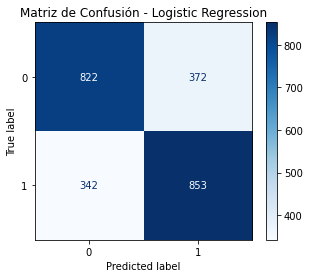

Classification Report:
              precision    recall  f1-score   support

     Clase 0       0.71      0.69      0.70      1194
     Clase 1       0.70      0.71      0.70      1195

    accuracy                           0.70      2389
   macro avg       0.70      0.70      0.70      2389
weighted avg       0.70      0.70      0.70      2389


Model: Random Forest


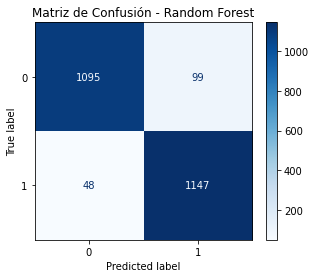

Classification Report:
              precision    recall  f1-score   support

     Clase 0       0.96      0.92      0.94      1194
     Clase 1       0.92      0.96      0.94      1195

    accuracy                           0.94      2389
   macro avg       0.94      0.94      0.94      2389
weighted avg       0.94      0.94      0.94      2389


Model: Decision Tree


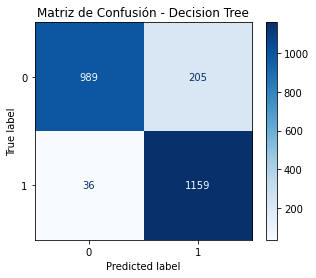

Classification Report:
              precision    recall  f1-score   support

     Clase 0       0.96      0.83      0.89      1194
     Clase 1       0.85      0.97      0.91      1195

    accuracy                           0.90      2389
   macro avg       0.91      0.90      0.90      2389
weighted avg       0.91      0.90      0.90      2389


Resumen General:
                 Model  Accuracy    Recall  F1 Score
0  Logistic Regression  0.701130  0.701125  0.701080
1        Random Forest  0.938468  0.938459  0.938439
2        Decision Tree  0.899121  0.899091  0.898608


In [23]:
results = {'Model': [], 'Accuracy': [], 'Recall': [], 'F1 Score': []}

for name, model in models.items():
    print(f'\nModel: {name}')
    
    model.fit(X_train, y_train)                
    y_pred = model.predict(X_valid)            
    
    acc = accuracy_score(y_valid, y_pred)
    recall = recall_score(y_valid, y_pred, average='macro') 
    f1 = f1_score(y_valid, y_pred, average='macro')

    results['Model'].append(name)
    results['Accuracy'].append(acc)
    results['Recall'].append(recall)
    results['F1 Score'].append(f1)

    cm = confusion_matrix(y_valid, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    # Plot the confusion matrix
    fig, ax = plt.subplots(figsize=(5,4))
    disp.plot(ax=ax, cmap='Blues')
    plt.title(f'Matriz de Confusión - {name}')
    plt.show()
    
    report = classification_report(y_valid, y_pred, target_names=['Clase 0', 'Clase 1'])
    print('Classification Report:')
    print(report)

results_df = pd.DataFrame(results)
print('\nResumen General:')
print(results_df)

Test Accuracy: 0.9569
Test Recall: 0.9841
Test F1 Score: 0.9580

Classification Report:
              precision    recall  f1-score   support

     Clase 0       0.98      0.93      0.96      1195
     Clase 1       0.93      0.98      0.96      1194

    accuracy                           0.96      2389
   macro avg       0.96      0.96      0.96      2389
weighted avg       0.96      0.96      0.96      2389



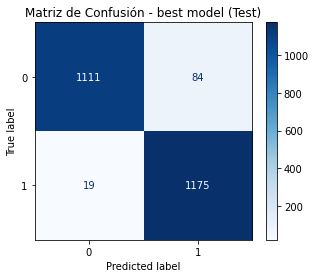

In [24]:
best_model = models['Random Forest']
best_model.fit(pd.concat([pd.DataFrame(X_train), pd.DataFrame(X_valid)]), pd.concat([y_train, y_valid]))

y_test_pred = best_model.predict(X_test)

test_acc = accuracy_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Recall: {test_recall:.4f}')
print(f'Test F1 Score: {test_f1:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_test_pred, target_names=['Clase 0', 'Clase 1']))

cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(5,4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión - best model (Test)')
plt.show()

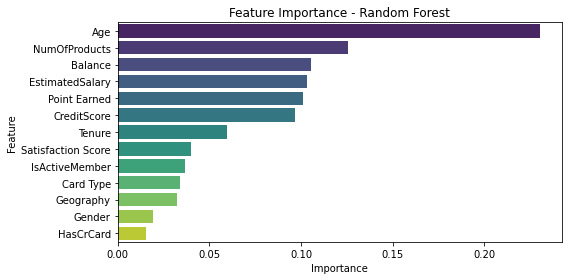

In [ ]:
importances = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': data_encoded.columns[1:-1],
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()